# Gene expression clustering

**Goal:**
Cluster gene expression. Identify clusters of genes with similar profiles of activation or repression.

**Simple Procedure:**
1. Align peaks of gene expression
2. Then cluster.
3. Visualize expression of clusters to identify patterns of similar activation.
4. Visualize the chromatin of the activation, and repression timepoints.

**More complex**
1. Compute a distance matrix
2. For every pair of entries, compute a correlation score by sliding the vector down each timepoint. The value of the distance will be the translation the outcome the maximal correlation.

**Expected outcome:**
There may be some similar patterns among similarly activated genes. For example, a gene that rapidly activates may exhibit a stronger change in nucleosome shift than a gene that gradually turns on.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.gene_clustering import GeneClustering

outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'

gene_clustering = GeneClustering(outdir)

In [231]:
gene_clustering.set_max_expression_threshold()

Genes with maximal expression for quantile: 0.5
is set at 10.58 expression level. 2789 genes meet this criteria


Selected 279 genes in the top 80% with quantile value greater than 1.15


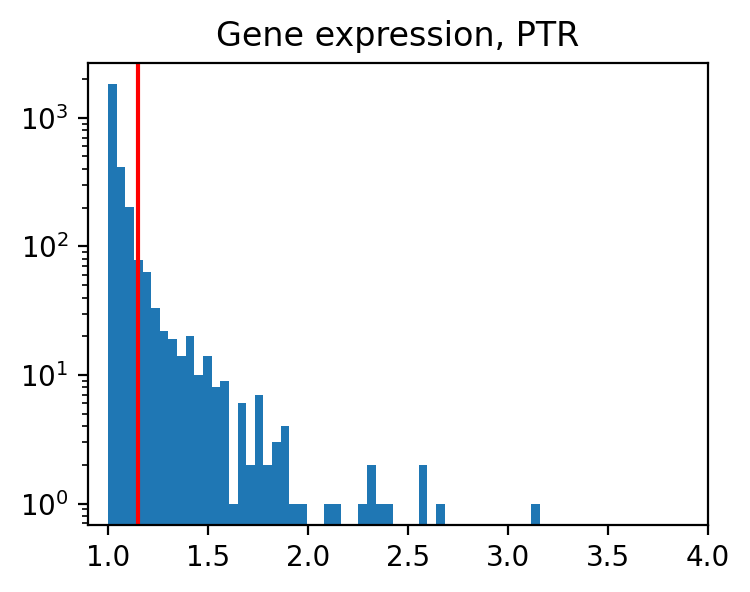

In [234]:
gene_clustering.set_threshold_ptr(0.9)

In [235]:
distance_matrix = gene_clustering.compute_distance_from_gene_expression()

0/279 - 00:00:00.134
100/279 - 00:00:10.426
200/279 - 00:00:17.066
00:00:18.357


In [236]:
from src.timer import Timer

# Compute a elbow curve of the inertia (sum of distances) to identify critical values of k
timer = Timer()

k_values = np.arange(2, 48, 1)
inertias = []

go_results_all = pd.DataFrame()
go_results_sigfig_all = pd.DataFrame()

for k in k_values:

    print(f"k={k}", end=', ')
    gene_clustering.cluster_expression(k)
    inertia = gene_clustering.kmedoids.inertia_
    inertias.append(inertia)
    print(f"    inertia={inertia:.2f}", end=', ')


k=2,     inertia=27.31, k=3,     inertia=22.81, k=4,     inertia=19.26, k=5,     inertia=16.82, k=6,     inertia=15.43, k=7,     inertia=14.36, k=8,     inertia=13.04, k=9,     inertia=12.25, k=10,     inertia=11.47, k=11,     inertia=10.96, k=12,     inertia=10.85, k=13,     inertia=10.52, k=14,     inertia=9.80, k=15,     inertia=9.32, k=16,     inertia=8.70, k=17,     inertia=8.21, k=18,     inertia=7.65, k=19,     inertia=6.84, k=20,     inertia=6.31, k=21,     inertia=6.24, k=22,     inertia=5.96, k=23,     inertia=5.50, k=24,     inertia=5.39, k=25,     inertia=5.28, k=26,     inertia=5.04, k=27,     inertia=4.81, k=28,     inertia=4.69, k=29,     inertia=4.49, k=30,     inertia=4.39, k=31,     inertia=4.21, k=32,     inertia=4.06, k=33,     inertia=3.95, k=34,     inertia=3.82, k=35,     inertia=3.73, k=36,     inertia=3.61, k=37,     inertia=3.45, k=38,     inertia=3.39, k=39,     inertia=3.32, k=40,     inertia=3.22, k=41,     inertia=3.18, k=42,     inertia=3.10, k=43,     in

Text(0, 0.5, 'Inertia, sum of distances')

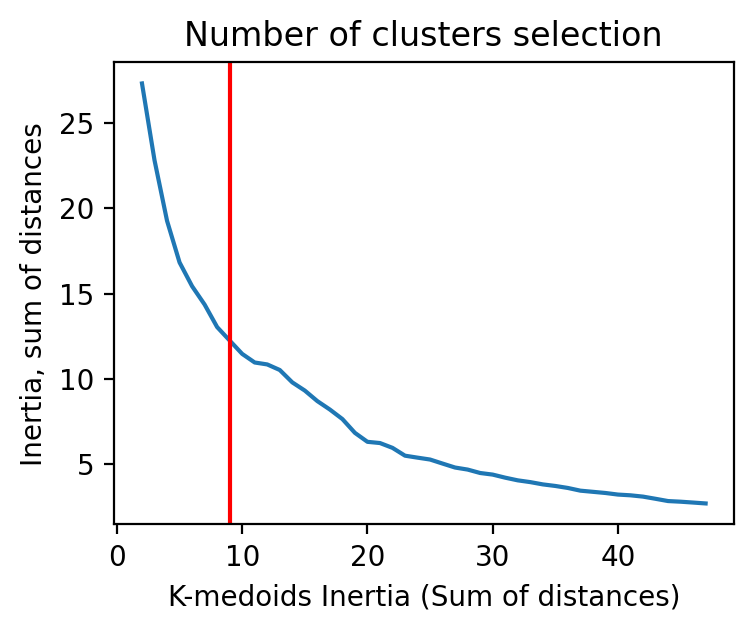

In [239]:
plt.figure(figsize=(4, 3))
plt.plot(k_values, inertias)
plt.axvline(9, c='red')
plt.xlabel("K-medoids Inertia (Sum of distances)")
plt.title("Number of clusters selection")
plt.ylabel("Inertia, sum of distances")


In [240]:
gene_clustering.cluster_expression(9)
gene_clustering.compute_medoids()
gene_clustering.compute_alignments_and_interesting_points_per_cluster()

<Figure size 500x300 with 0 Axes>

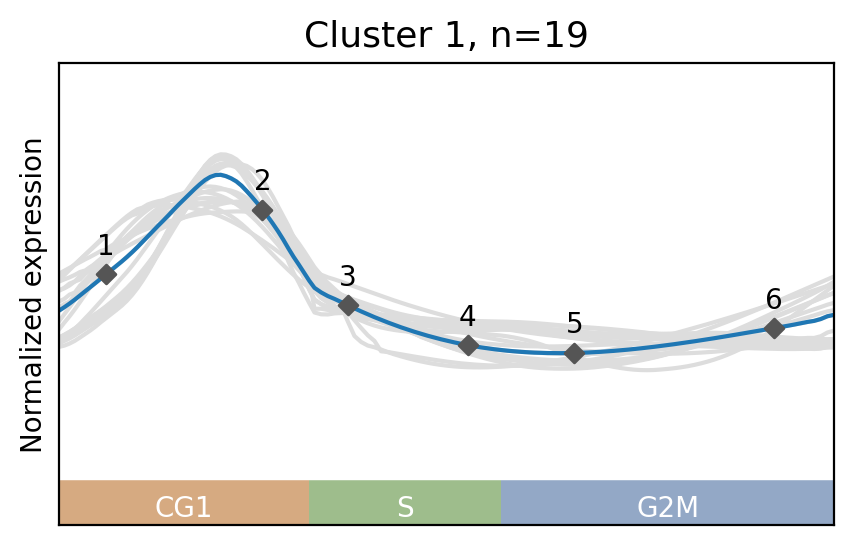

<Figure size 500x300 with 0 Axes>

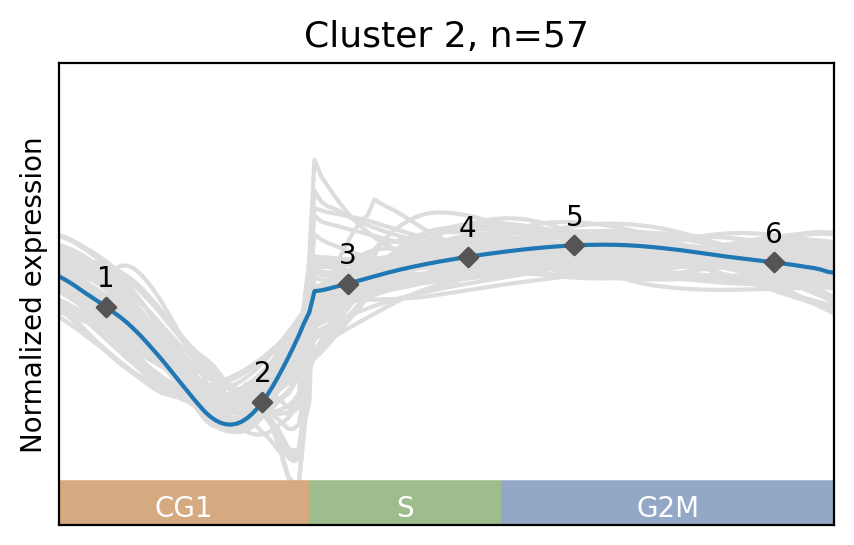

<Figure size 500x300 with 0 Axes>

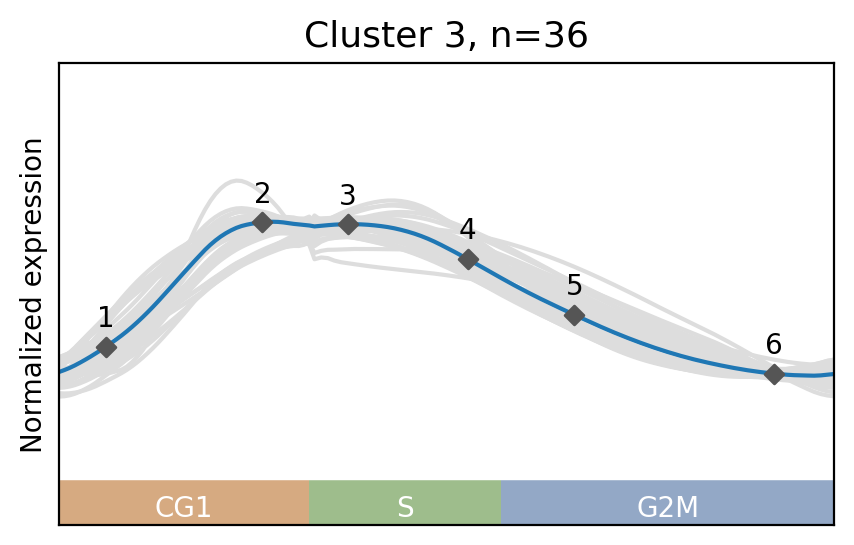

<Figure size 500x300 with 0 Axes>

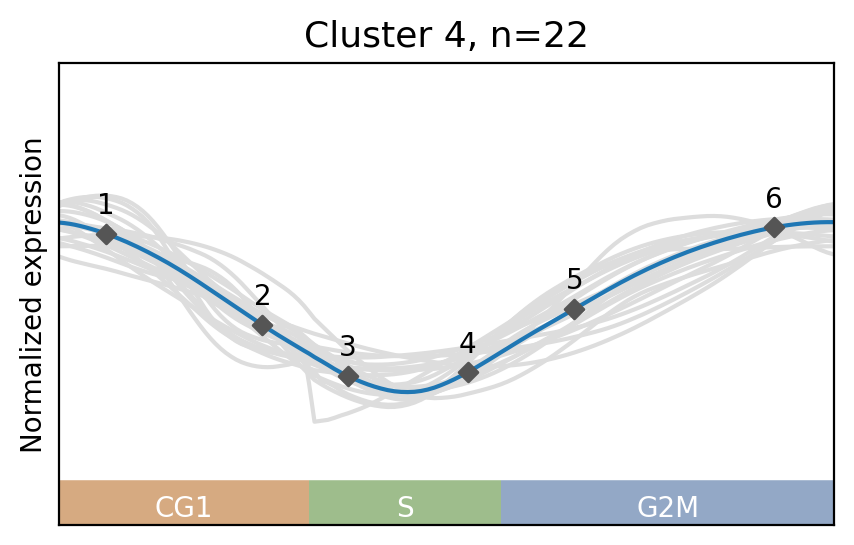

<Figure size 500x300 with 0 Axes>

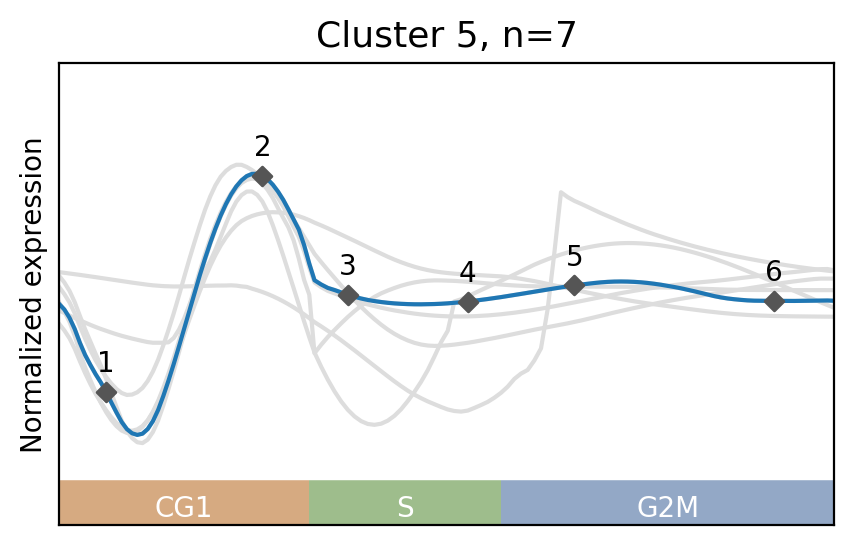

<Figure size 500x300 with 0 Axes>

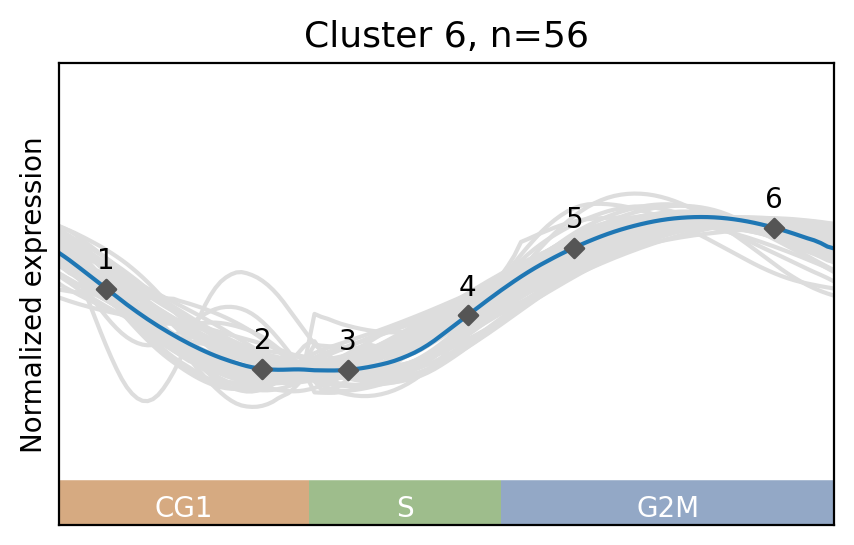

<Figure size 500x300 with 0 Axes>

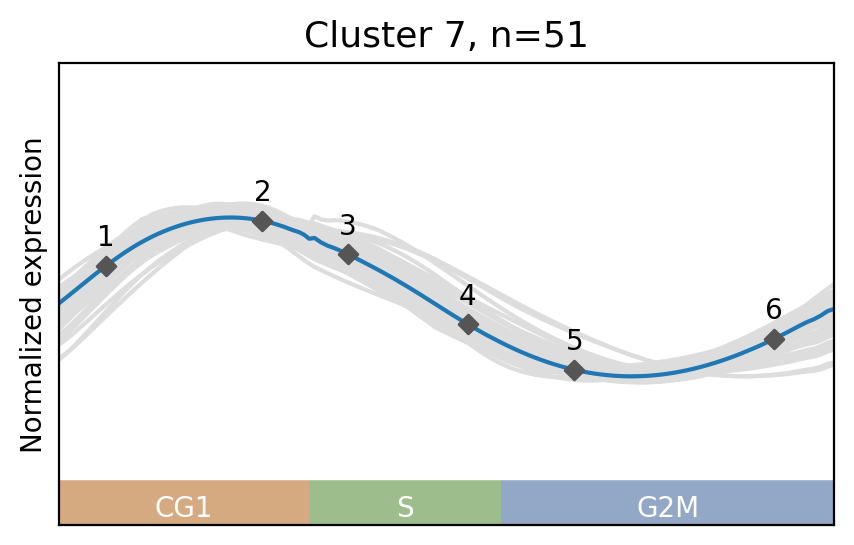

<Figure size 500x300 with 0 Axes>

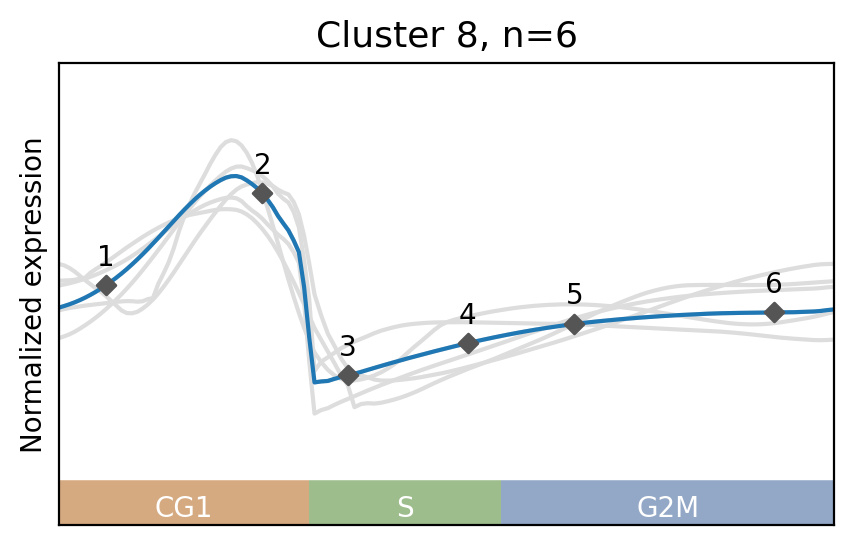

<Figure size 500x300 with 0 Axes>

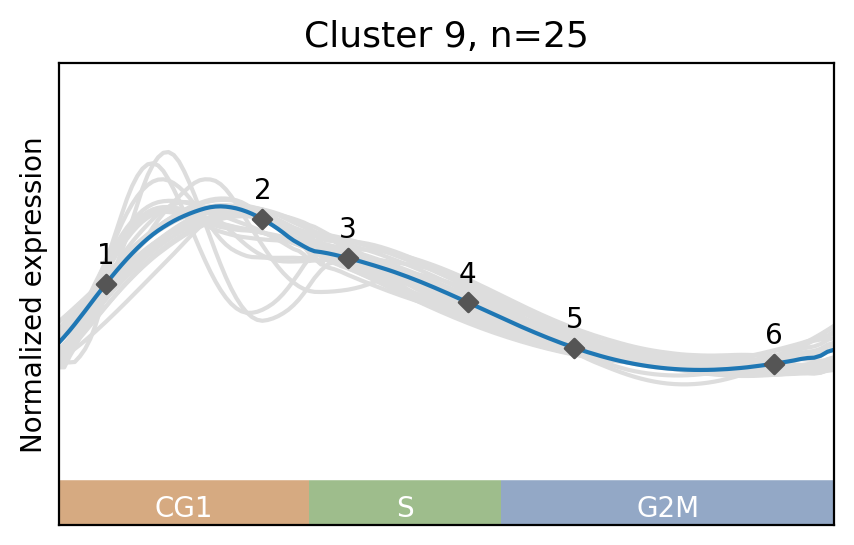

In [241]:
from src.figure_configs import FiguresConfig, save_figure_for_paper

plot_dir = (f'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/clustering/')

for cluster in range(1, gene_clustering.num_clusters+1):
    fig = plt.figure(figsize=(5, 3))
    gene_clustering.plot_aligned_cluster(cluster)
    save_figure_for_paper(f'{plot_dir}/expression_curves_cluster{cluster}.png')
    #plt.close(fig)


In [242]:
gene_clustering.run_gene_ontology_on_clustered_genes(gene_clustering.clustered_expression)

data/go.obo: fmt(1.2) rel(2018-08-29) 47,313 Terms


In [243]:
gene_clustering.print_go_results()

Cluster 1
  Citrate metabolic process

Cluster 2
  Sulfate assimilation
  Methionine metabolic process
  Polyphosphate metabolic process
  Vacuolar transporter chaperone complex

Cluster 3
  Nuclear nucleosome
  Chromatin assembly or disassembly
  DNA binding
  Replication fork protection complex

Cluster 4
  MCM complex
  Mitotic S phase
  Nuclear pre-replicative complex
  Pre-replicative complex assembly involved in nuclear cell cycle DNA replication
  DNA strand elongation involved in DNA replication
  DNA replication preinitiation complex
  Replication fork protection complex
  Double-strand break repair via break-induced replication
  DNA replication origin binding
  DNA replication initiation
  Four-way junction helicase activity
  Single-stranded DNA-dependent ATPase activity
  Single-stranded DNA binding
  DNA unwinding involved in DNA replication
  ATP-dependent 3'-5' DNA helicase activity
  Chromatin binding

Cluster 6
  Cellular bud neck contractile ring
  Cellular bud neck


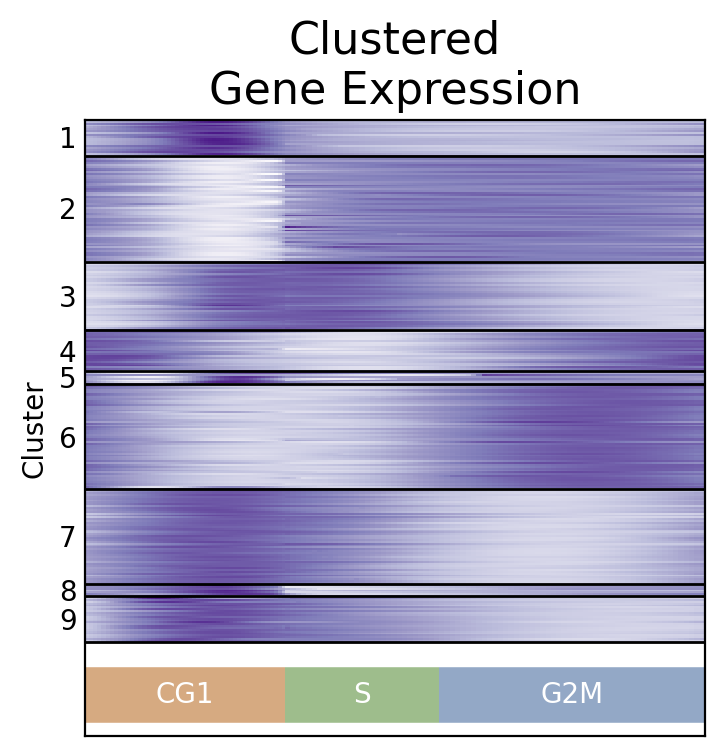

In [244]:
gene_clustering.plot_clustered_heatmap()
save_figure_for_paper(f'{plot_dir}/cluster_heatmap.png')


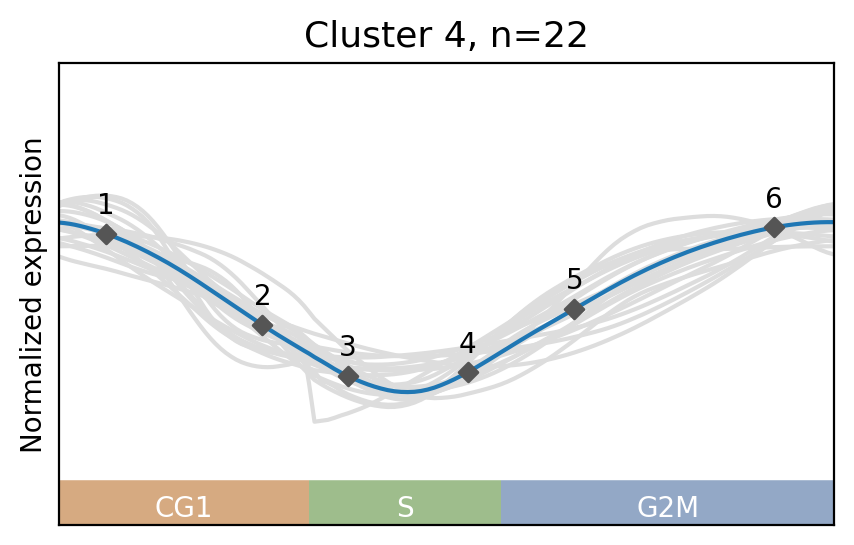

In [245]:
gene_clustering.plot_aligned_cluster(4)

In [246]:
TSS_chromatin_dir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/chromatin/'
PAS_chromatin_dir = 'output/deconvolve_sharedg1_g0066_11x11_PAS_2024_09_12/chromatin/'
gene_clustering.set_chromatin_dirs(TSS_chromatin_dir, PAS_chromatin_dir)

Cluster 1
Shape of the loaded F: (178, 2093)
(178, 2093)
1/19 - 00:00:00.021
Shape of the loaded F: (178, 2093)
(178, 2093)
1/19 - 00:00:00.020
Cluster 2
Shape of the loaded F: (178, 2093)
(178, 2093)
1/57 - 00:00:00.029
Shape of the loaded F: (178, 2093)
(178, 2093)
1/57 - 00:00:00.027
Cluster 3
Shape of the loaded F: (178, 2093)
(178, 2093)
1/36 - 00:00:00.023
Shape of the loaded F: (178, 2093)
(178, 2093)
1/36 - 00:00:00.022
Cluster 4
Shape of the loaded F: (178, 2093)
(178, 2093)
1/22 - 00:00:00.012
Shape of the loaded F: (178, 2093)
(178, 2093)
1/22 - 00:00:00.014
Cluster 5
Shape of the loaded F: (178, 2093)
(178, 2093)
1/7 - 00:00:00.007
Shape of the loaded F: (178, 2093)
(178, 2093)
1/7 - 00:00:00.007
Cluster 6
Shape of the loaded F: (178, 2093)
(178, 2093)
1/56 - 00:00:00.026
Shape of the loaded F: (178, 2093)
(178, 2093)
1/56 - 00:00:00.026
Cluster 7
Shape of the loaded F: (178, 2093)
(178, 2093)
1/51 - 00:00:00.027
Shape of the loaded F: (178, 2093)
(178, 2093)
1/51 - 00:00:0

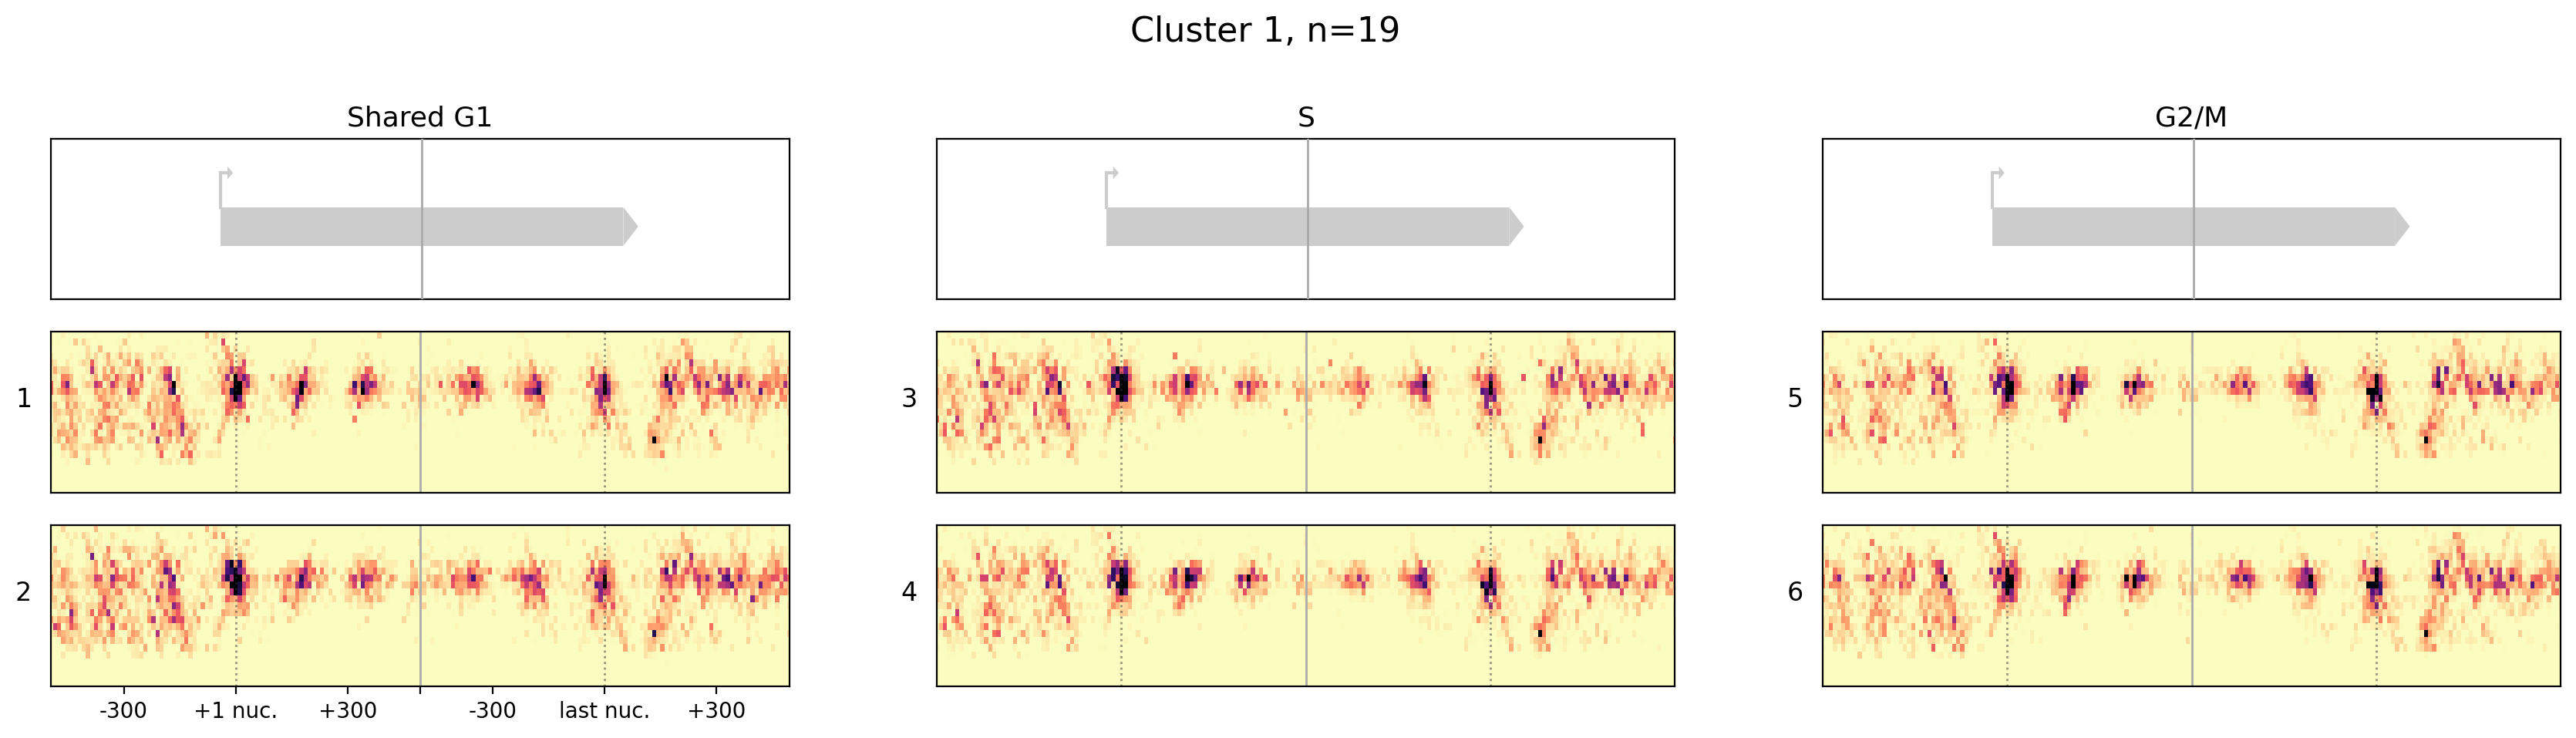

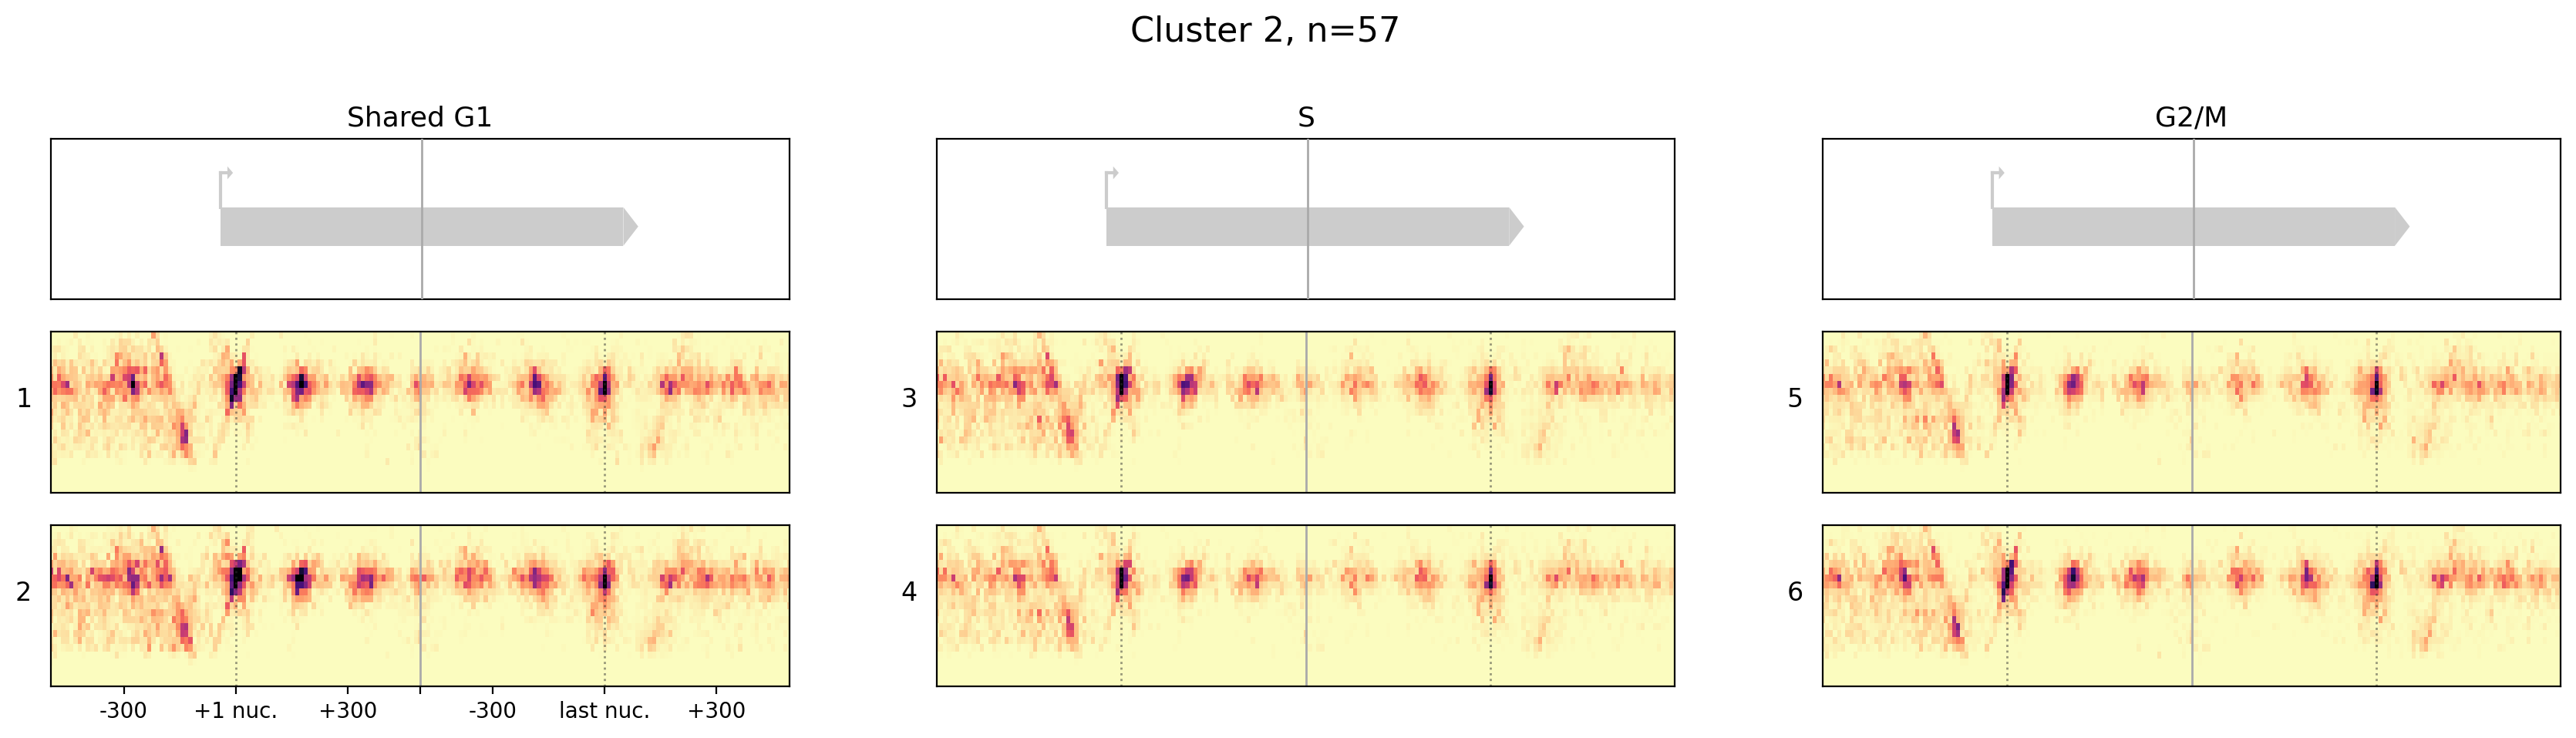

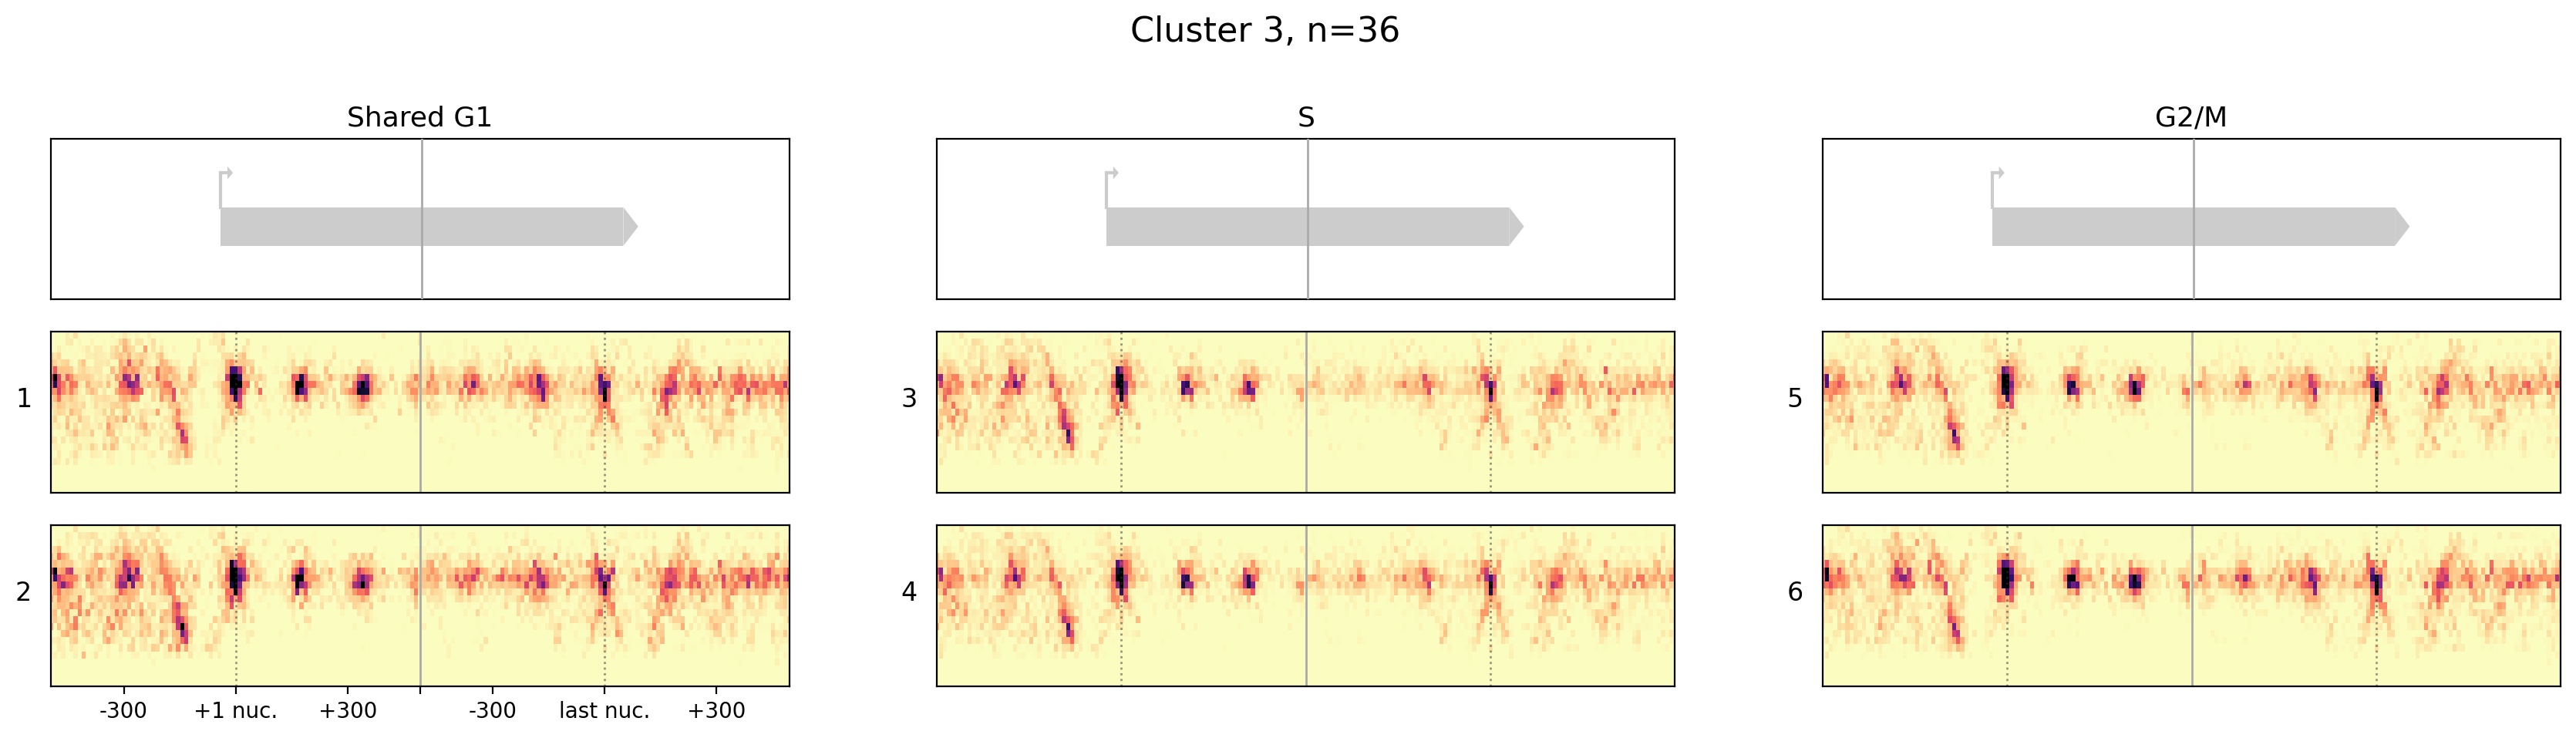

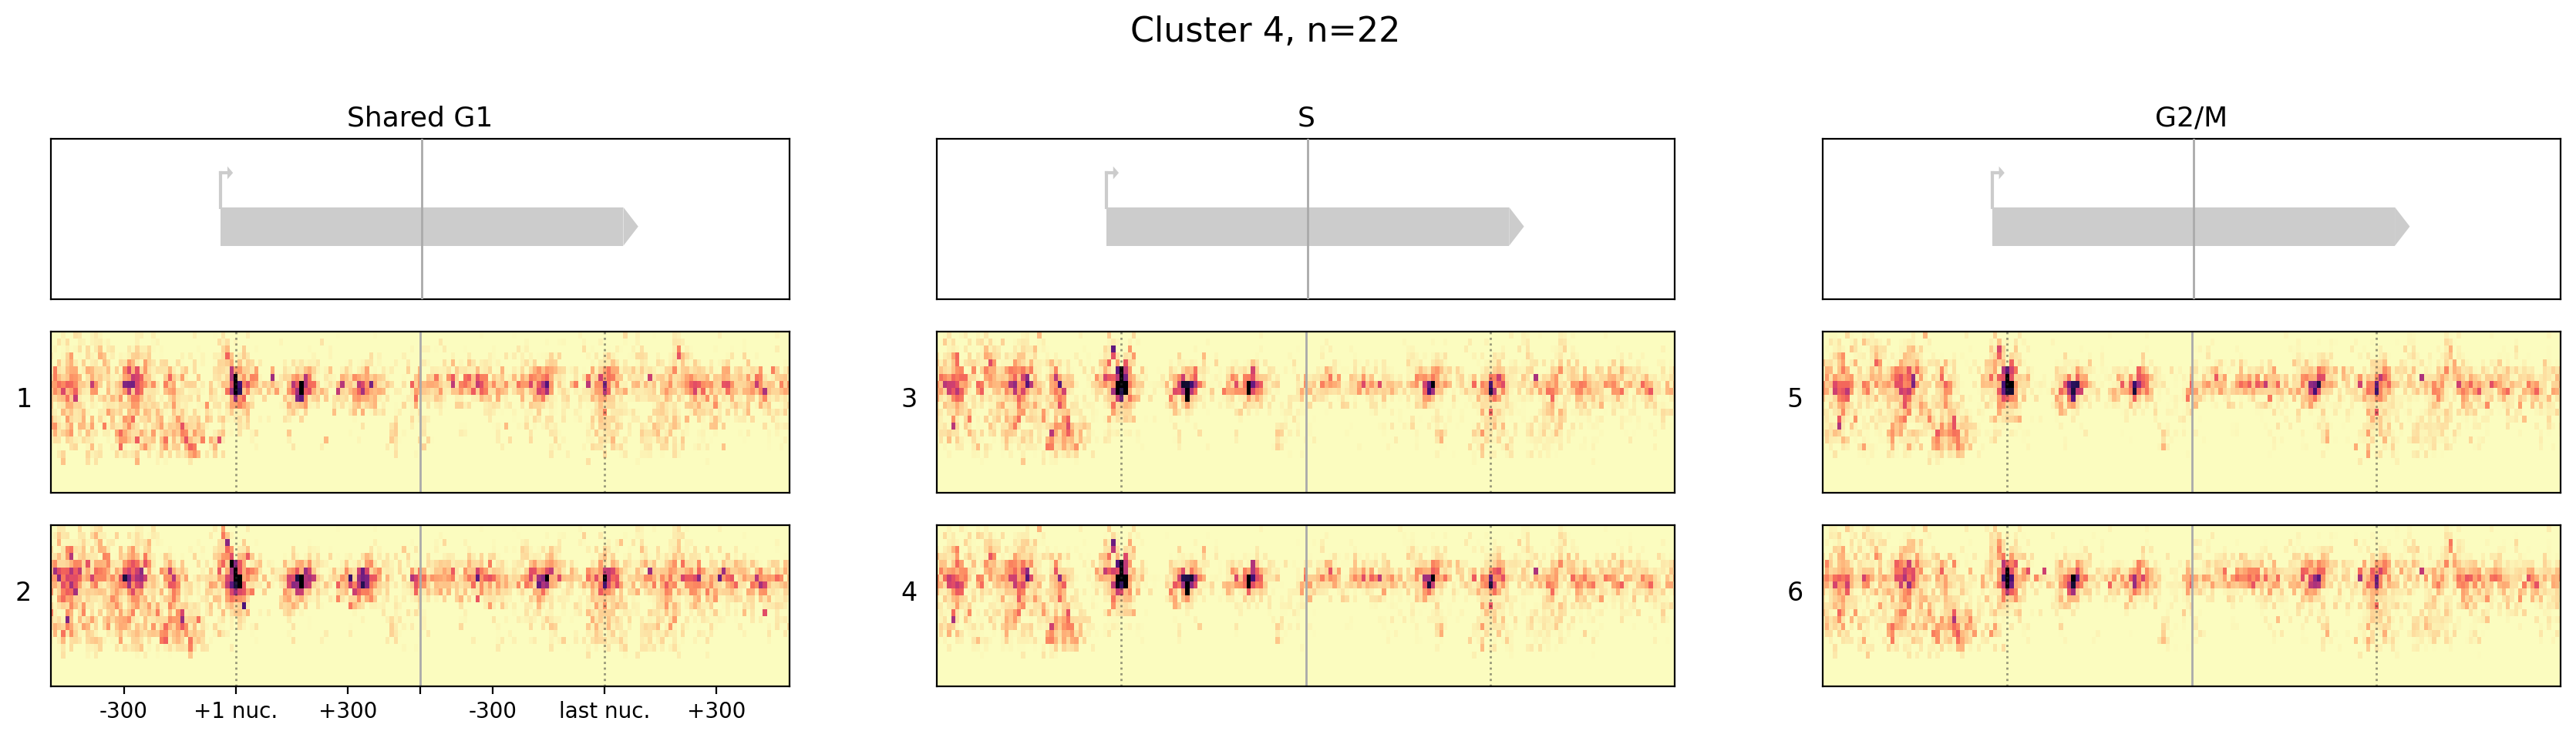

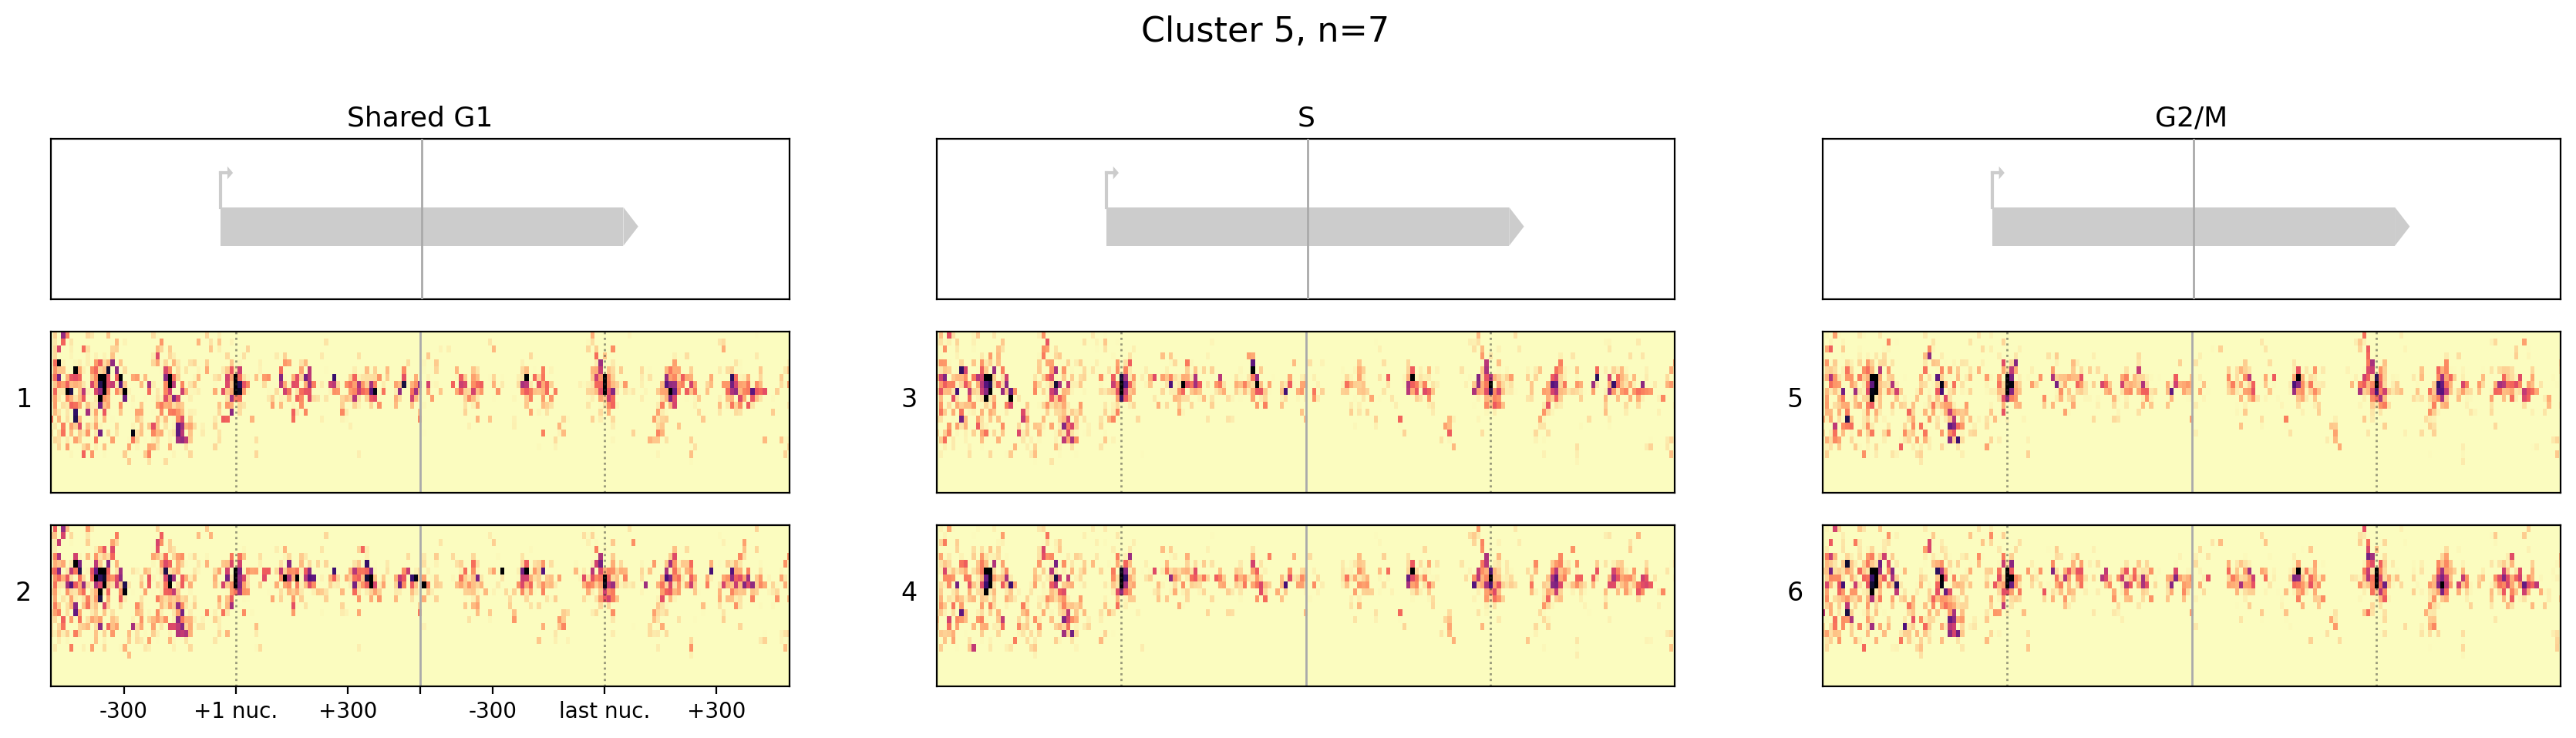

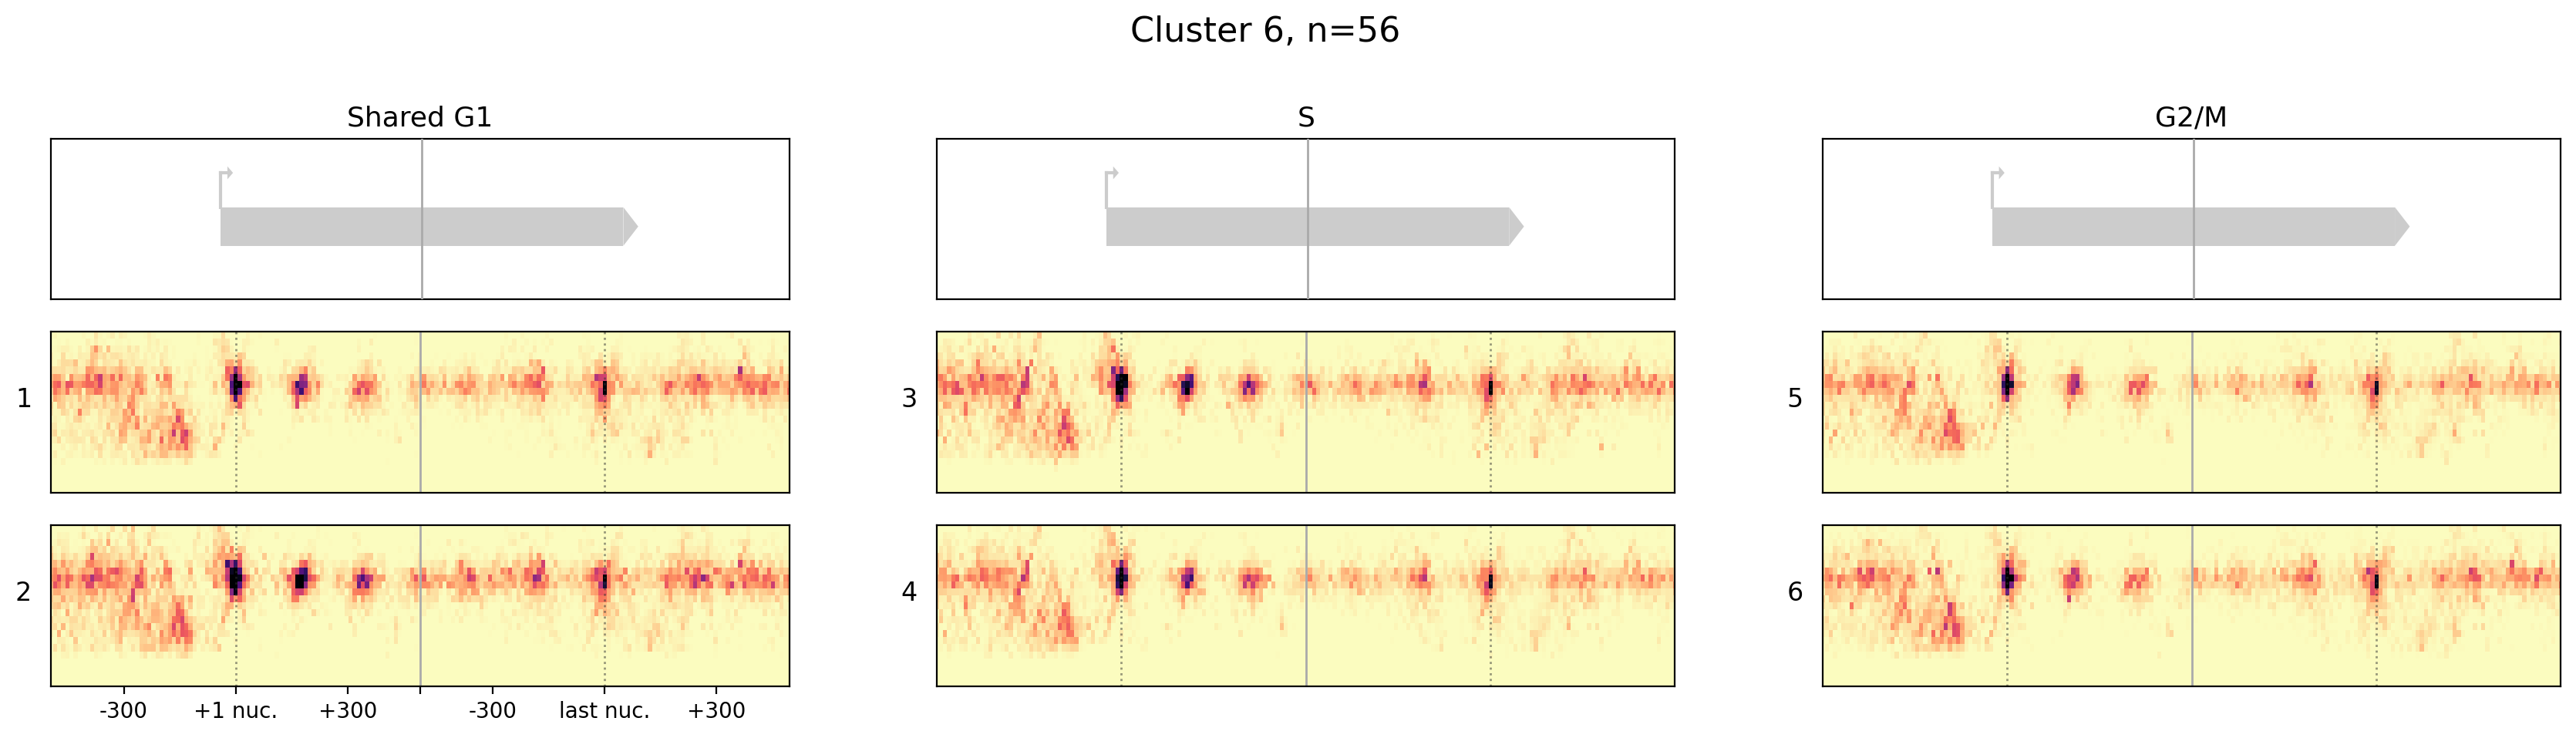

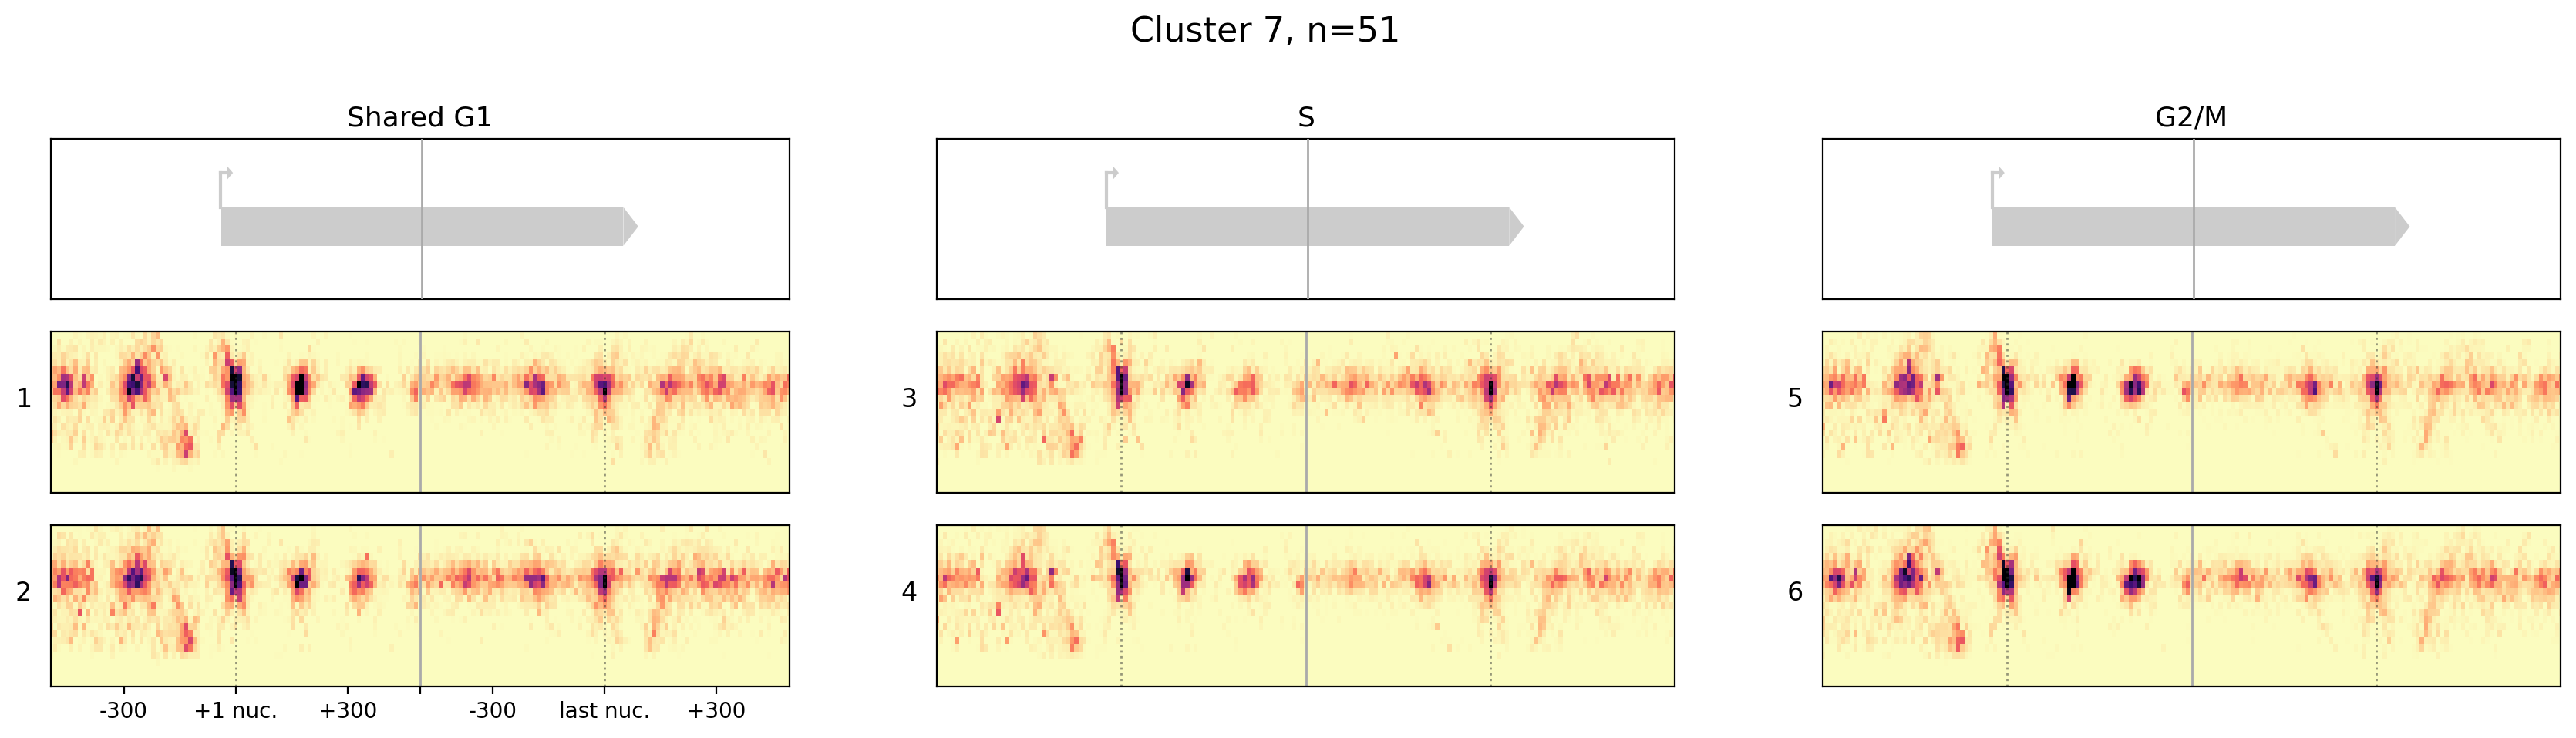

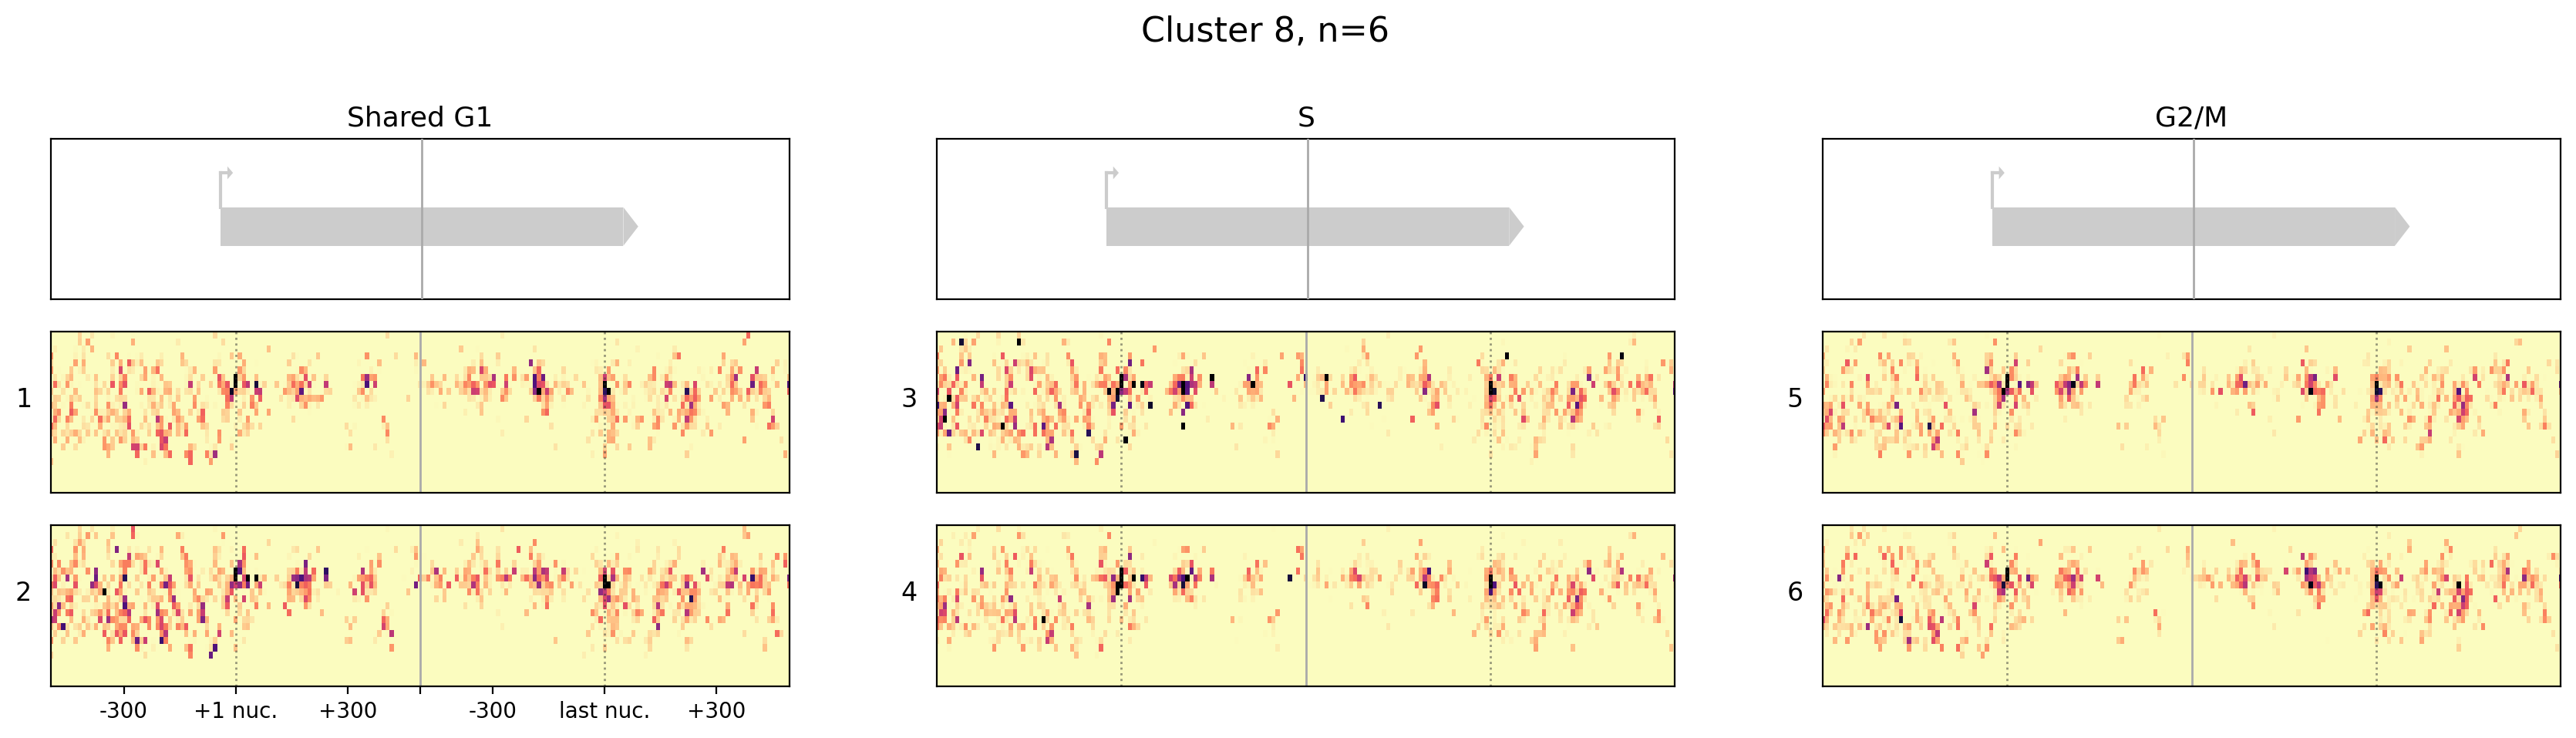

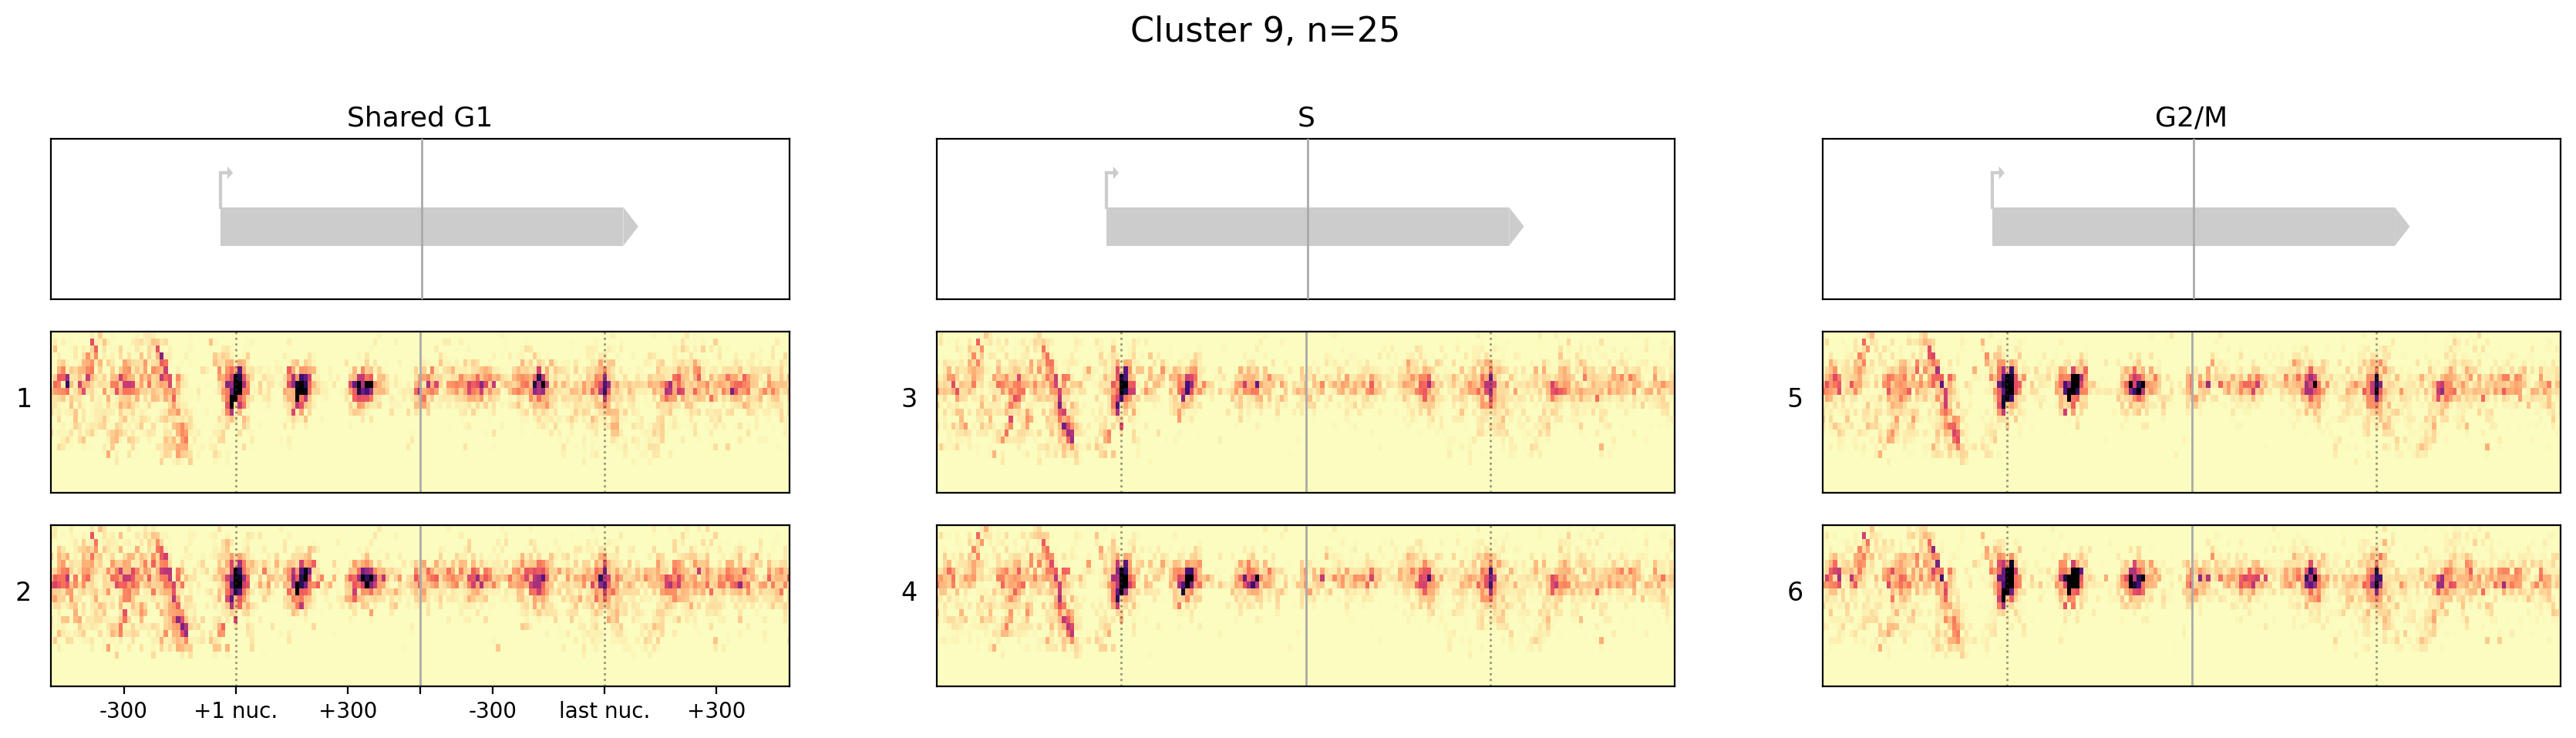

In [250]:
for cluster in range(1, gene_clustering.num_clusters+1):
    print(f"Cluster {cluster}")
    gene_clustering.load_chromatin_for_cluster(cluster)
    fig = gene_clustering.plot_chromatin_in_cluster()
    save_path = f'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/clustering/chromatin_{cluster}.png'
    save_figure_for_paper(save_path)


Cluster 4
Shape of the loaded F: (178, 2093)
(178, 2093)
1/22 - 00:00:00.012
Shape of the loaded F: (178, 2093)
(178, 2093)
1/22 - 00:00:00.013


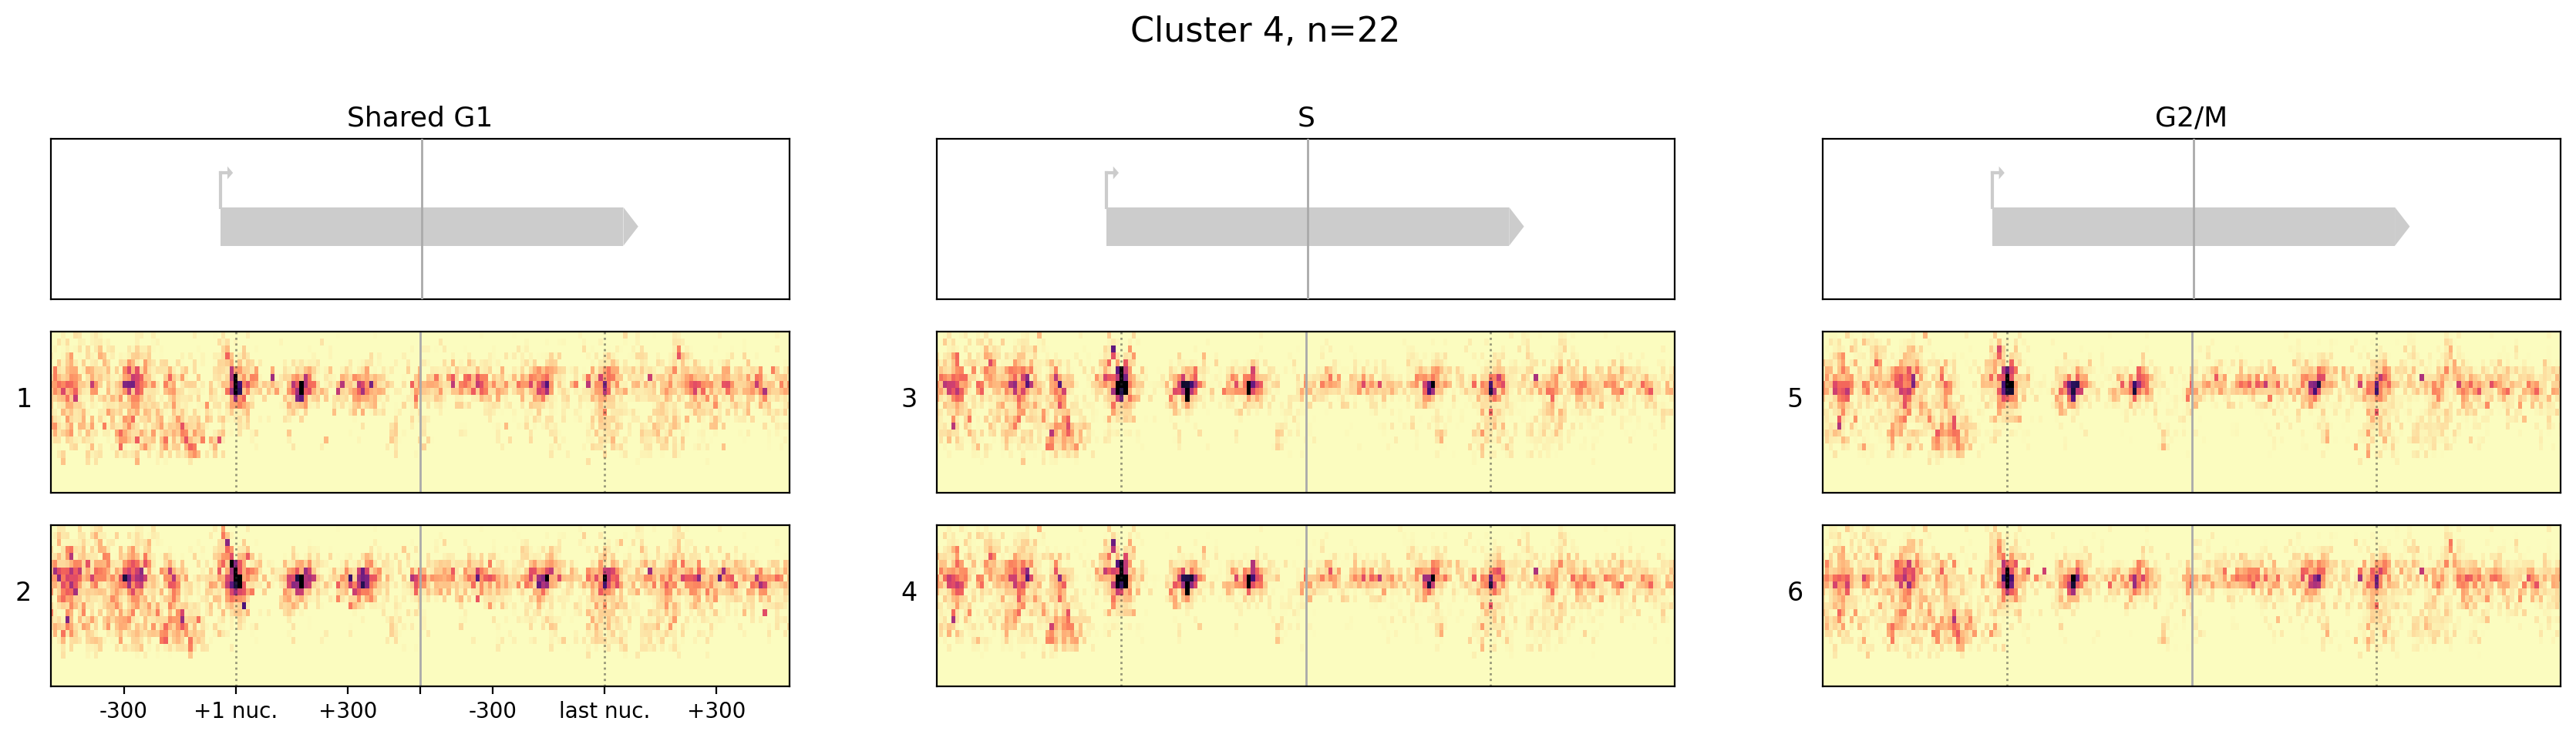

In [249]:
cluster = 4

print(f"Cluster {cluster}")
gene_clustering.load_chromatin_for_cluster(cluster)
fig = gene_clustering.plot_chromatin_in_cluster()
